In [4]:
import numpy as np
from glob import glob
from DNN.lw_spacenet import SeismicDataset, SeismicTrainer, create_data_loaders, UNet3D
import matplotlib.pyplot as plt
from util.plotting import plot_3d_array_interactive

In [2]:
def slice_data_chunks_with_stride(data, chunk_size=(128, 128, 128), stride=None):
    """
    Slice input data of shape (150, 150, 2000) into overlapping chunks of specified size.
    
    Args:
        data: Input numpy array of shape (150, 150, 2000)
        chunk_size: Tuple of (height, width, depth) for each chunk
        stride: Step size between chunks (default is half the chunk size for 50% overlap)
    
    Returns:
        List of numpy arrays, each of shape chunk_size
    """
    h, w, d = data.shape
    ch, cw, cd = chunk_size
    
    # Default stride is half the chunk size for 50% overlap
    if stride is None:
        stride = (ch // 2, cw // 2, cd // 2)
    
    sh, sw, sd = stride
    
    chunks = []
    
    # Calculate how many chunks we can fit in each dimension with the given stride
    h_steps = max(1, (h - ch) // sh + 1)
    w_steps = max(1, (w - cw) // sw + 1)
    d_steps = max(1, (d - cd) // sd + 1)
    
    for i in range(h_steps):
        for j in range(w_steps):
            for k in range(d_steps):
                start_h, end_h = i * sh, i * sh + ch
                start_w, end_w = j * sw, j * sw + cw
                start_d, end_d = k * sd, k * sd + cd
                
                # Ensure we don't exceed the data bounds
                end_h = min(end_h, h)
                end_w = min(end_w, w)
                end_d = min(end_d, d)
                
                # Adjust start positions if we're near the boundary
                start_h = max(0, end_h - ch)
                start_w = max(0, end_w - cw)
                start_d = max(0, end_d - cd)
                
                chunk = data[start_h:end_h, start_w:end_w, start_d:end_d]
                chunks.append(chunk)
    del chunks[0:5]
    return np.array(chunks)

def normalize_seismic(seismic):
    """Normalize seismic to [0, 1] using min-max."""
    min_val = np.min(seismic)
    max_val = np.max(seismic)
    if max_val - min_val == 0:
        return np.zeros_like(seismic)
    return (seismic - min_val) / (max_val - min_val)

def normalize_rgt(rgt):
    """Normalize RGT by mean and std."""
    mean_val = np.mean(rgt)
    std_val = np.std(rgt)
    if std_val == 0:
        return np.zeros_like(rgt)
    normalized = (rgt - mean_val) / std_val
    return normalized

In [ ]:
sort_key = lambda path: path.rsplit('2026', 1)[-1]

seismic_paths = sorted(glob("/mnt/storage/nnseismic/synthetic_data/raw/seismicCubes_cumsum_fullstack*.npy"), key=sort_key)
age_paths = sorted(glob("/mnt/storage/nnseismic/synthetic_data/raw/faulted_age*.npy"), key=sort_key)

seis_chunk_norm = []
age_chunk = []

for s_path, a_path in zip(seismic_paths, age_paths):
    # Load and process seismic
    sdf = np.load(s_path).astype(np.float32)
    seis_chunk_norm.extend(slice_data_chunks_with_stride(normalize_seismic(sdf)))
    
    # Load and chunk age
    adf = np.load(a_path).astype(np.float32)
    age_chunk.extend(slice_data_chunks_with_stride(adf))

# Normalize age chunks
age_chunk_norm = [normalize_rgt(chunk) for chunk in age_chunk]

In [28]:
import os
import shutil
from sklearn.model_selection import train_test_split

def clean_directory(directory_path):
    """Remove all files in the specified directory."""
    if os.path.exists(directory_path):
        for filename in os.listdir(directory_path):
            file_path = os.path.join(directory_path, filename)
            if os.path.isfile(file_path):
                os.remove(file_path)

indices = list(range(len(seis_chunk_norm)))
train_indices, val_indices = train_test_split(
    indices, test_size=0.1, random_state=42
)
fold = "/mnt/storage/nnseismic/synthetic_data/"

# Clean directories before writing files
train_seis_dir = f"{fold}train/seis/"
train_rgt_dir = f"{fold}train/rgt/"
val_seis_dir = f"{fold}val/seis/"
val_rgt_dir = f"{fold}val/rgt/"

clean_directory(train_seis_dir)
clean_directory(train_rgt_dir)
clean_directory(val_seis_dir)
clean_directory(val_rgt_dir)

# Save training chunks
for idx in train_indices:
    seis_chunk_norm[idx].tofile(f"{fold}train/seis/{idx:04d}.dat")
    age_chunk_norm[idx].tofile(f"{fold}train/rgt/{idx:04d}.dat")

# Save validation chunks
for idx in val_indices:
    seis_chunk_norm[idx].tofile(f"{fold}val/seis/{idx:04d}.dat")
    age_chunk_norm[idx].tofile(f"{fold}val/rgt/{idx:04d}.dat")

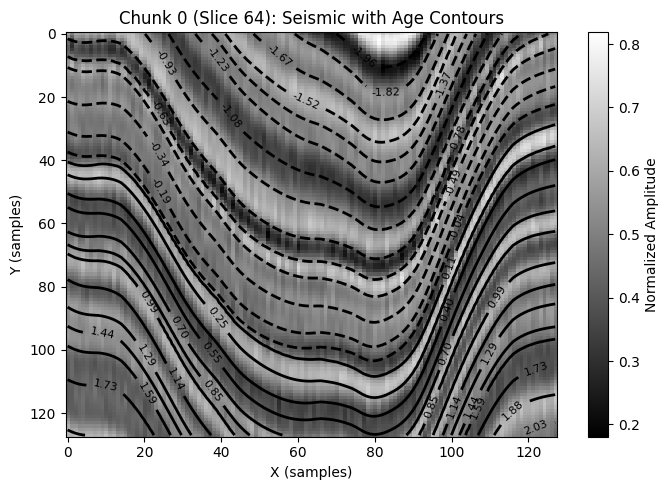

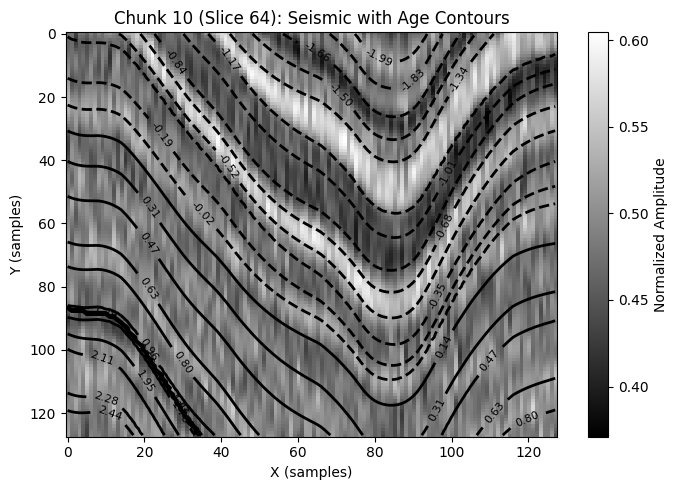

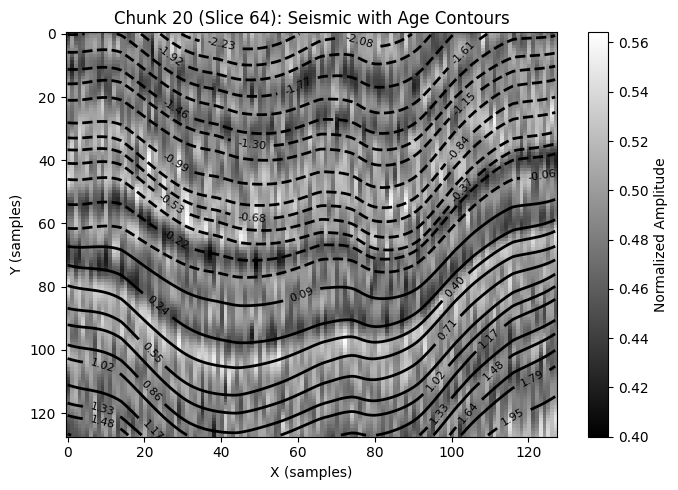

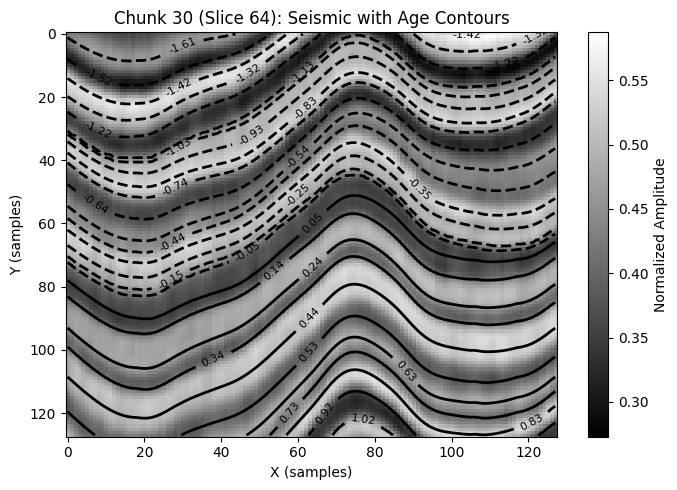

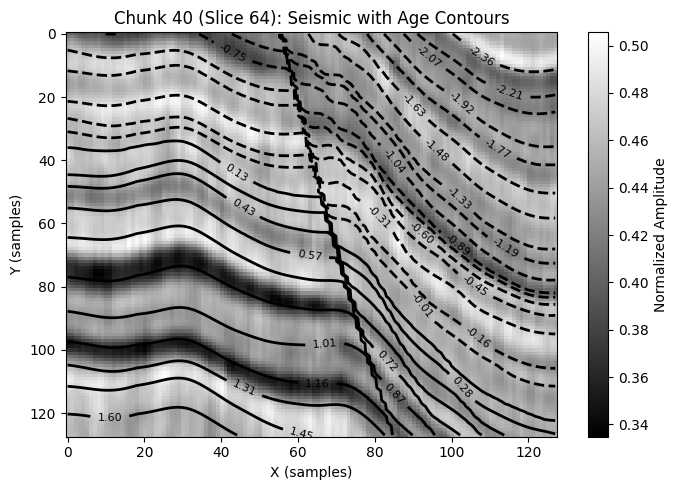

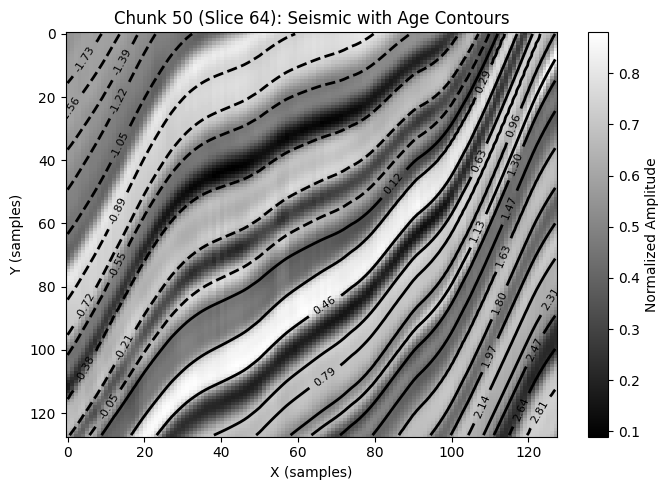

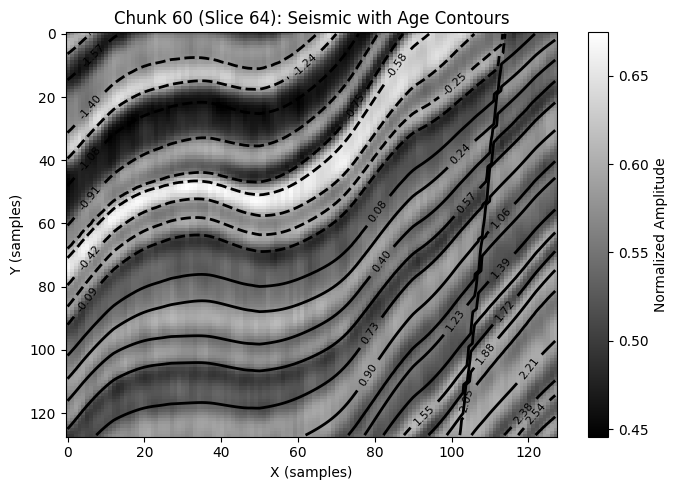

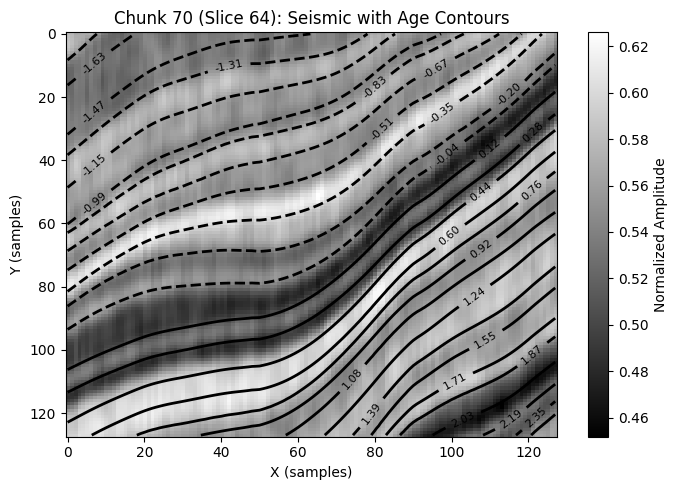

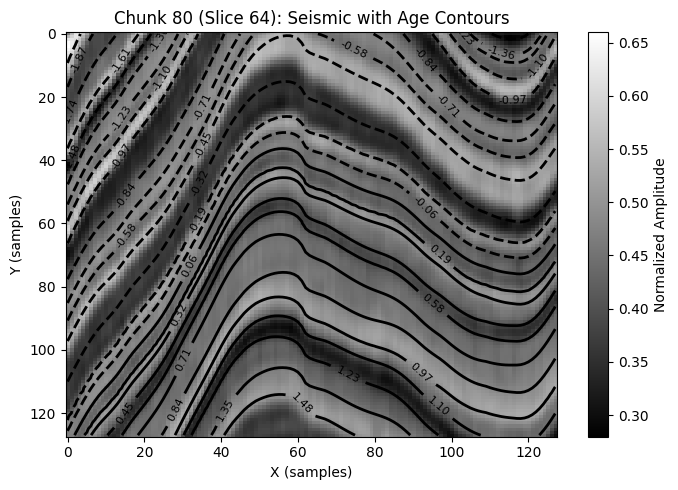

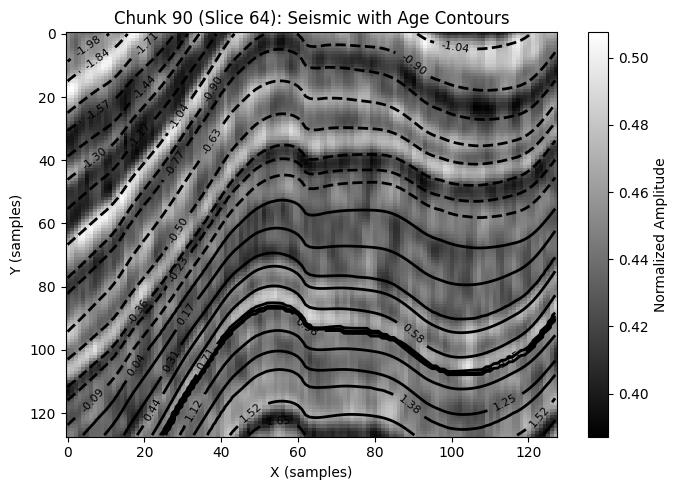

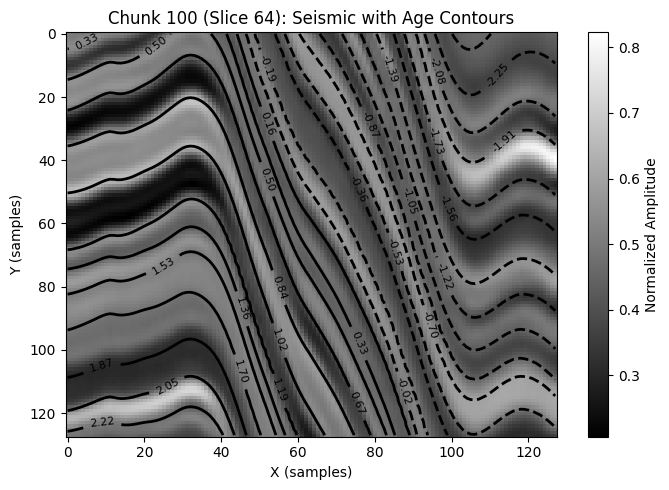

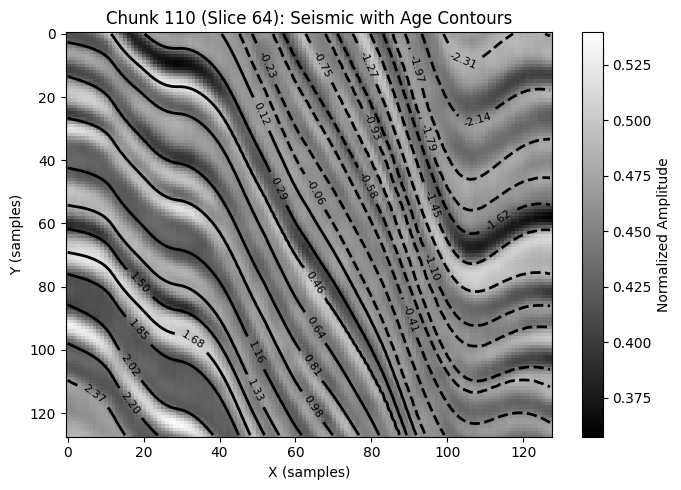

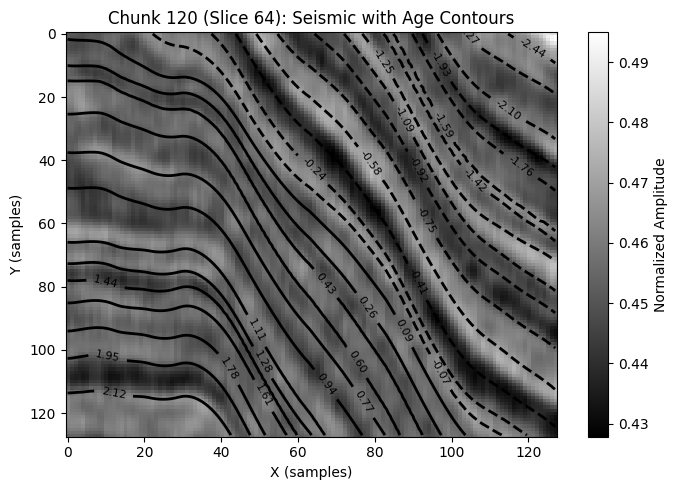

In [27]:
step = 10
slice_idx = 64
# Define tuple to extract a 2D slice from the 3D chunk: (index, all, all)
slicer = (slice_idx, slice(None), slice(None))

for idx in range(0, len(seis_chunk_norm), step):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Apply slicer to reduce 3D chunks (128,128,128) to 2D planes (128,128)
    seis_2d = seis_chunk_norm[idx][slicer].T
    age_2d = age_chunk_norm[idx][slicer]
    
    im = ax.imshow(seis_2d, cmap='gray', aspect='auto')
    fig.colorbar(im, ax=ax, label='Normalized Amplitude')
    
    contour_levels = np.linspace(age_2d.min(), age_2d.max(), 30)
    contours = ax.contour(
        age_2d.T, 
        levels=contour_levels, 
        colors='black', 
        linewidths=2
    )
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')
    
    ax.set_title(f'Chunk {idx} (Slice {slice_idx}): Seismic with Age Contours')
    ax.set_xlabel('X (samples)')
    ax.set_ylabel('Y (samples)')
    plt.tight_layout()
    plt.show()

In [4]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = f'../data/DNN models/.logs/run_{timestamp}'

dataset = SeismicDataset(seis_chunk_norm, age_chunk_norm, augm=True)
train_loader, val_loader = create_data_loaders(dataset, batch_size=3)
model = UNet3D(in_channels=1, out_channels=1, init_features=16, smoothing_kernel_size=3)
trainer = SeismicTrainer(model, train_loader, val_loader, log_dir=log_dir, tv_loss_weight=0.008)

/home/spaceswimmer/miniconda3/envs/diploma/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
len(dataset)

500

In [6]:
trainer.train(num_epochs=20, save_dir=f"../data/DNN models/run-{timestamp}")


Epoch 1/20
------------------------------
Batch 0/134, Loss: 1.070312
Batch 5/134, Loss: 0.695312
Batch 10/134, Loss: 0.558594
Batch 15/134, Loss: 0.703125
Batch 20/134, Loss: 0.292969
Batch 25/134, Loss: 0.414062
Batch 30/134, Loss: 0.578125
Batch 35/134, Loss: 0.435547
Batch 40/134, Loss: 0.746094
Batch 45/134, Loss: 0.289062
Batch 50/134, Loss: 0.539062
Batch 55/134, Loss: 0.478516
Batch 60/134, Loss: 0.398438
Batch 65/134, Loss: 0.464844
Batch 70/134, Loss: 0.527344
Batch 75/134, Loss: 0.443359
Batch 80/134, Loss: 0.582031
Batch 85/134, Loss: 0.408203
Batch 90/134, Loss: 0.500000
Batch 95/134, Loss: 0.478516
Batch 100/134, Loss: 0.328125
Batch 105/134, Loss: 0.730469
Batch 110/134, Loss: 0.449219
Batch 115/134, Loss: 0.496094
Batch 120/134, Loss: 0.494141
Batch 125/134, Loss: 0.769531
Batch 130/134, Loss: 0.636719
Train Loss: 0.527183
Val Loss: 0.476562
Saved best model with val_loss: 0.476562

Epoch 2/20
------------------------------
Batch 0/134, Loss: 0.550781
Batch 5/134, Loss

([0.5271834188432836,
  0.398251661613806,
  0.208036963619403,
  0.10438104885727612,
  0.08456830836054105,
  0.054566340659981345,
  0.06100509415811567,
  0.0512021192863806,
  0.056043027052238806,
  0.034242544601212684,
  0.03718954057835821,
  0.03298175868703358,
  0.034007058214785446,
  0.026673729739972014,
  0.025734972597947763,
  0.025193854944029852,
  0.03510432456856343,
  0.047806013875932835,
  0.03806088575676306,
  0.03584813359958022],
 [0.4765625,
  0.31833065257352944,
  0.13605813419117646,
  0.08391256893382353,
  0.07516659007352941,
  0.10493738511029412,
  0.05976418887867647,
  0.05063404756433824,
  0.04439410041360294,
  0.04937744140625,
  0.03682574103860294,
  0.03380629595588235,
  0.032183478860294115,
  0.031167423023897058,
  0.030984317555147058,
  0.03152286305147059,
  0.04128130744485294,
  0.05045094209558824,
  0.03540757123161765,
  0.030747357536764705])

In [ ]:
seis, rgt = dataset[450]
seis, rgt = seis.float(), rgt.float()
plot_3d_array_interactive(seis[0], axis='x')
plot_3d_array_interactive(rgt[0], axis='x', cmap='viridis')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

In [ ]:
# seis, rgt = dataset[3]
# seis, rgt = seis.float(), rgt.float()
# plot_3d_array_interactive(seis[0], axis='x')
# plot_3d_array_interactive(rgt[0], axis='x', cmap='viridis')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…